1. Project Objective
2. Import Libraries
3. Load Dataset
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Selection and Scaling
7. Finding Optimal Clusters
8. K-Means Clustering
9. Segment Analysis
10. Business Insights and Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/store_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nData types:")
print(df.dtypes)

Shape of dataset: (1000, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Data types:
CustomerID                  int64
Gender                     object
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object


In [4]:
print("Missing values:\n")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

Duplicate rows: 0


In [5]:
df.describe(include="all")

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,997,994.000000,996.000000,994.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,F,NaN,NaN,NaN
freq,NaN,522,NaN,NaN,NaN
mean,1499.500000,NaN,38.935614,57.149096,42.645875
std,288.819436,NaN,13.399880,28.628506,20.101589
min,1000.000000,NaN,18.000000,15.000000,1.000000
25%,1249.750000,NaN,30.000000,34.975000,31.000000
50%,1499.500000,NaN,36.000000,49.000000,47.000000
75%,1749.250000,NaN,44.000000,79.400000,57.000000


## Data Cleaning
Handling missing values and preparing the dataset for analysis.

In [6]:
df.columns = [
    "customer_id",
    "gender",
    "age",
    "annual_income",
    "spending_score"
]

df.head()

,customer_id,gender,age,annual_income,spending_score
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [7]:
df.isnull().sum()

customer_id       0
gender            3
age               6
annual_income     4
spending_score    6
dtype: int64

In [8]:
df["age"].fillna(df["age"].median(), inplace=True)
df["annual_income"].fillna(df["annual_income"].median(), inplace=True)
df["spending_score"].fillna(df["spending_score"].median(), inplace=True)

In [9]:
df["gender"].fillna(df["gender"].mode()[0], inplace=True)

In [10]:
df["gender"] = df["gender"].map({"M": 0, "F": 1})

In [11]:
df.isnull().sum()

customer_id       0
gender            0
age               0
annual_income     0
spending_score    0
dtype: int64

In [12]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     1000 non-null   int64  
 1   gender          1000 non-null   int64  
 2   age             1000 non-null   float64
 3   annual_income   1000 non-null   float64
 4   spending_score  1000 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 39.2 KB


,customer_id,gender,age,annual_income,spending_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1499.500000,0.525000,38.918000,57.116500,42.672000
std,288.819436,0.499624,13.361505,28.575769,20.043956
min,1000.000000,0.000000,18.000000,15.000000,1.000000
25%,1249.750000,0.000000,30.000000,35.075000,31.750000
50%,1499.500000,1.000000,36.000000,49.000000,47.000000
75%,1749.250000,1.000000,44.000000,79.325000,57.000000
max,1999.000000,1.000000,80.000000,144.100000,92.000000


In [13]:
df.isnull().sum()

customer_id       0
gender            0
age               0
annual_income     0
spending_score    0
dtype: int64

## Exploratory Data Analysis (EDA)

In this section we explore customer demographics, income distribution,
and spending behavior to understand patterns before applying clustering.

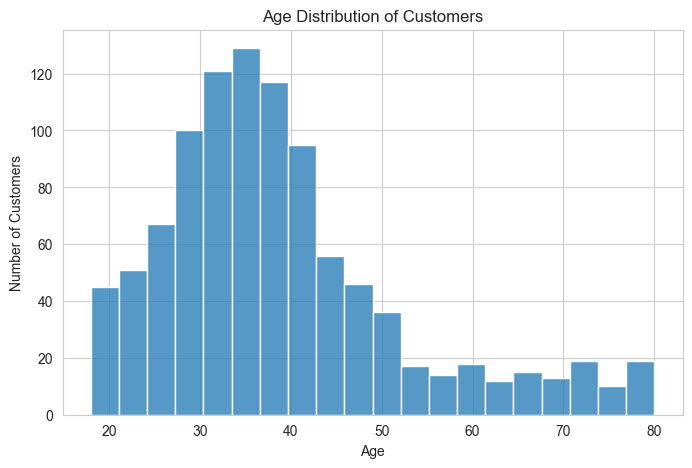

In [14]:
plt.figure()

sns.histplot(df["age"], bins=20)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.savefig("../visuals/age_distribution.png")

plt.show()

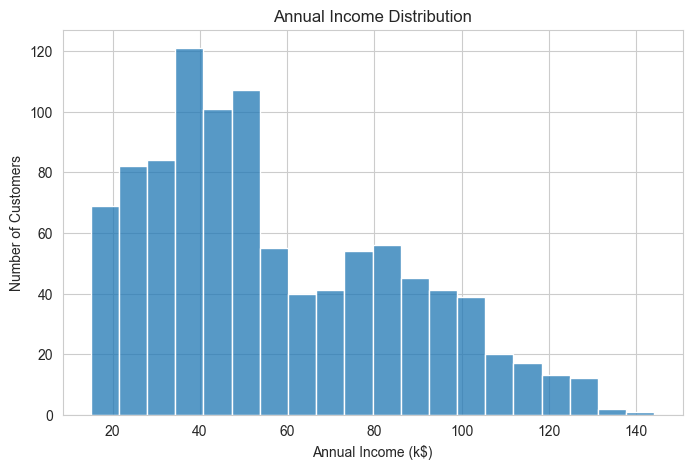

In [15]:
plt.figure()

sns.histplot(df["annual_income"], bins=20)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.savefig("../visuals/income_distribution.png")

plt.show()

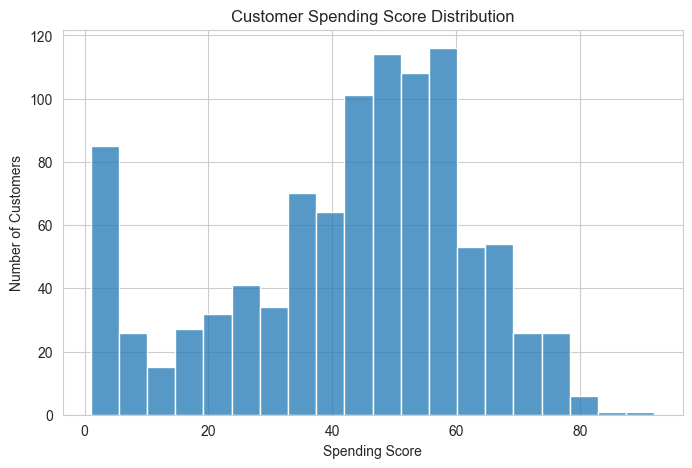

In [16]:
plt.figure()

sns.histplot(df["spending_score"], bins=20)

plt.title("Customer Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.savefig("../visuals/spending_distribution.png")

plt.show()

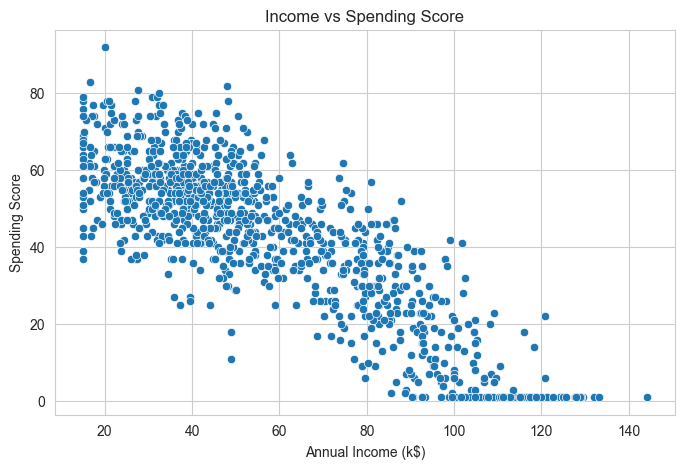

In [17]:
plt.figure()

sns.scatterplot(
    x=df["annual_income"],
    y=df["spending_score"]
)

plt.title("Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.savefig("../visuals/income_vs_spending.png")

plt.show()

### Observations from Exploratory Analysis

1. The age distribution shows most customers are between 25–45 years old.

2. Annual income is widely distributed, with most customers earning between 30k and 80k.

3. Spending scores vary significantly across customers, indicating different purchasing behaviors.

4. The income vs spending scatter plot suggests a negative relationship where higher income customers tend to have lower spending scores in this dataset.

These patterns suggest that customers may form distinct behavioral groups, making clustering a suitable approach for segmentation.

## Finding Optimal Number of Clusters (Elbow Method)

Before applying K-Means clustering, we determine the optimal number of customer segments using the Elbow Method.

In [18]:
X = df[["annual_income", "spending_score"]]

In [19]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

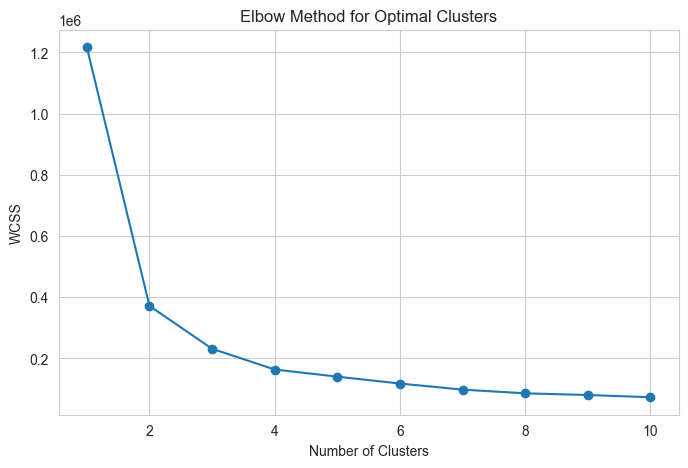

In [20]:
plt.figure()

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.savefig("../visuals/elbow_method.png")

plt.show()